## Imported the Liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error, mean_squared_error

## Dataset

In [2]:
df = pd.read_csv('Salary.csv')

## Exploratory Data Analysis(EDA)

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [5]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [6]:
df.shape

(35, 2)

# Checking for the Outlayers

<Axes: >

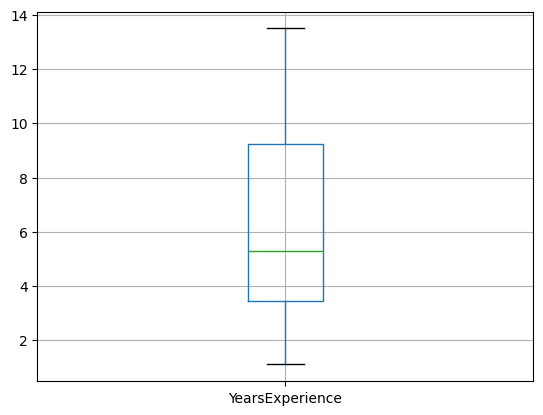

In [7]:
df.boxplot(column='YearsExperience')

## Defining the X,y Model

In [8]:
X = df.drop('Salary',axis=1)
y = df['Salary']

## Train Test Split 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=8)

## Regression Model

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
lr.coef_

array([8736.81559824])

In [13]:
X_train.columns

Index(['YearsExperience'], dtype='str')

In [14]:
pd.DataFrame({'Features': X_train.columns, 'Cofficients': lr.coef_})

,Features,Cofficients
0,YearsExperience,8736.815598


In [21]:
y_pred = lr.predict(X_test)
y_pred

array([ 97567.32595612,  38156.97988811,  80093.69475965, 112419.91247312,
        39904.34300776, 104556.77843471,  63493.745123  ])

## Checking the Model

In [16]:
mean_squared_error(y_test, y_pred)

19964888.816822972

In [17]:
mean_absolute_error(y_test,y_pred)

3611.3872290745703

In [18]:
r2_score(y_test,y_pred)

0.9756533181957102

In [19]:
root_mean_squared_error(y_test, y_pred)

4468.208680984246

In [20]:
mean_absolute_percentage_error(y_test,y_pred)

0.05763288684994473